In [1]:
import pandas as pd
import requests
import math
import matplotlib.pyplot as plt

In [2]:
MAX_RESULTS_PER_PAGE = 200

In [3]:
keywords_df = pd.read_csv('keywords_fm.csv')

In [4]:
keywords_df

,Keywords,Variations
0,dna,"dna, genomics, genomic, genome, genomes, metag..."
1,foundation_model,"foundation model, foundation genome model, fou..."
2,architecture,"transformers, transformer, attention, state sp..."


In [5]:
def create_openalex_query(df:pd.DataFrame, baseurl='https://api.openalex.org/works?filter=', max_results_per_page=MAX_RESULTS_PER_PAGE)->str:
    """Creates a query url for openalex api using a csv
        Uses OR for values in the same row of the df, while using AND between rows

    Args:
        df (pd.DataFrame): _description_
        baseurl (str, optional): _description_. Defaults to 'https://api.openalex.org/works?filter='.
        max_results_per_page (int, optional): _description_. Defaults to 200.

    Returns:
        str: query url for openalex api
    """       
    query_parts = []
    
    for _, row in df.iterrows():
        variations = row['Variations'].split(", ")
        # Join the variations with "|" and wrap in fulltext.search:""
        #query_part = 'fulltext.search:"' + '"|"'.join(variations) + '"'
        query_part = 'search:"' + '"|"'.join(variations) + '"'
        query_parts.append(query_part)
    #join with , to get AND statement
    query_string = ",".join(query_parts)
    max_results_per_page = '&per-page=' + str(max_results_per_page)
    
    return f"{baseurl}{query_string}{max_results_per_page}"

In [6]:
def get_request(url: str):
    """Returns metadata and results of a OpenAlex API query, handling pagination.

    Args:
        url (str): query for OpenAlex API

    Returns:
        dict: Combined metadata from all pages
        list: Combined results from all pages
    """
    all_results = []
    current_page = 1
    total_pages = None

    while True:
        paginated_url = f"{url}&page={current_page}"
        
        response = requests.get(paginated_url)
        
        if response.status_code == 200:
            data = response.json()
            if current_page == 1:
                meta = data['meta']
                total_pages = math.ceil(meta['count'] / MAX_RESULTS_PER_PAGE)
            
            results = data['results']    
            all_results.extend(results) 
                
            if current_page >= total_pages:
                break
            
            current_page += 1
            
        else:
            print(f"Error: {response.status_code}")
            break
    
    return meta, all_results

In [7]:
query = create_openalex_query(keywords_df)
query

'https://api.openalex.org/works?filter=abstract.search:"dna"|"genomics"|"genomic"|"genome"|"genomes"|"metagenome"|"dna sequence"|"metagenomics"|"microbiome",abstract.search:"foundation model"|"foundation genome model"|"foundation dna model"|"foundation models",abstract.search:"transformers"|"transformer"|"attention"|"state space models"|"bert"|"ttt"|"test-time training"|"test time training"|"hyena"|"artificial intellegence"|"deep learning"&per-page=200'

In [8]:
#query = 'https://api.openalex.org/works?filter=fulltext.search:dna,fulltext.search:foundation model,fulltext.search:transformer&per-page=200'
query = 'https://api.openalex.org/works?filter=search:("dna" AND "foundation model" AND "transformer")'

In [9]:
meta, reports = get_request(query)

In [10]:
meta

{'count': 47,
 'db_response_time_ms': 625,
 'page': 1,
 'per_page': 200,
 'groups_count': None}

In [11]:
[report['title'] for report in reports]

['The Nucleotide Transformer: Building and Evaluating Robust Foundation Models for Human Genomics',
 'Mamba: Linear-Time Sequence Modeling with Selective State Spaces',
 'HyenaDNA: Long-Range Genomic Sequence Modeling at Single Nucleotide Resolution',
 'HyenaDNA: Long-Range Genomic Sequence Modeling at Single Nucleotide Resolution.',
 'DNABERT-2: Efficient Foundation Model and Benchmark For Multi-Species Genome',
 'SegmentNT: annotating the genome at single-nucleotide resolution with DNA foundation models',
 'Distinguishing word identity and sequence context in DNA language models',
 'GFETM: Genome Foundation-based Embedded Topic Model for scATAC-seq Modeling',
 'Investigating the performance of foundation models on human 3’UTR sequences',
 'Are Genomic Language Models All You Need? Exploring Genomic Language Models on Protein Downstream Tasks',
 'Nicheformer: a foundation model for single-cell and spatial omics',
 'ChatNT: A Multimodal Conversational Agent for DNA, RNA and Protein Tas

In [60]:
columns_to_keep = ['doi','title','relevance_score', 'publication_year', 'publication_date', 'cited_by_count']
result_df = pd.json_normalize(reports)[columns_to_keep]

In [52]:
#n_original = meta['count']
#print(f"n original: {n_original}")
#result_df = result_df[~result_df.duplicated(subset=['doi'])]
#print(f"n after removing duplicates doi: {len(result_df)}")

#result_df = result_df[result_df['publication_year']>=2017]
# print(f"n after filtering >= 2017: {len(result_df)}")

n original: 1627
n after removing duplicates doi: 1621
n after filtering >= 2017: 855


In [53]:
result_df

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
0,https://doi.org/10.1186/s40168-018-0470-z,Optimizing taxonomic classification of marker-...,1324.234300,2018,2018-05-17,3806
1,https://doi.org/10.1145/3458754,Domain-Specific Language Model Pretraining for...,1295.152300,2021,2021-10-15,1014
5,https://doi.org/10.1109/access.2019.2945545,Comprehensive Review of Artificial Neural Netw...,809.169560,2019,2019-01-01,435
13,https://doi.org/10.1038/s41591-022-01981-2,Multimodal biomedical AI,690.781900,2022,2022-09-01,384
22,https://doi.org/10.1186/s40537-020-00392-9,Deep Learning applications for COVID-19,612.747860,2021,2021-01-11,270
...,...,...,...,...,...,...
1606,https://doi.org/10.37008/978-65-5368-316-7.07....,EDUCAÇÃO NA ERA DIGITAL: DESAFIOS E POTENCIALI...,4.415123,2023,2023-01-01,0
1607,https://doi.org/10.32920/25413838.v1,Implicit Entity Recognition and Linking in Tweets,4.275013,2024,2024-03-18,0
1608,https://doi.org/10.32920/25413838,Implicit Entity Recognition and Linking in Tweets,4.253092,2024,2024-03-18,0
1610,https://doi.org/10.3726/b21307,Recherche littéraire / Literary Research,3.989805,2023,2023-11-13,0


In [41]:
#result_df.to_csv('openalex_initialsearchgg.csv', index=False)

In [55]:
result_df['title'].to_list()

['Optimizing taxonomic classification of marker-gene amplicon sequences with QIIME 2’s q2-feature-classifier plugin',
 'Domain-Specific Language Model Pretraining for Biomedical Natural Language Processing',
 'Comprehensive Review of Artificial Neural Network Applications to Pattern Recognition',
 'Multimodal biomedical AI',
 'Deep Learning applications for COVID-19',
 'Artificial intelligence in COVID-19 drug repurposing',
 'Current progress and open challenges for applying deep learning across the biosciences',
 'Remaining trouble spots with computational thinking',
 'Artificial Intelligence for COVID-19 Drug Discovery and Vaccine Development',
 'AlphaFold2 and its applications in the fields of biology and medicine',
 'A Comprehensive Review of the COVID-19 Pandemic and the Role of IoT, Drones, AI, Blockchain, and 5G in Managing its Impact',
 'The Nucleotide Transformer: Building and Evaluating Robust Foundation Models for Human Genomics',
 'Recent advances and applications of deep l

## Summary Stats

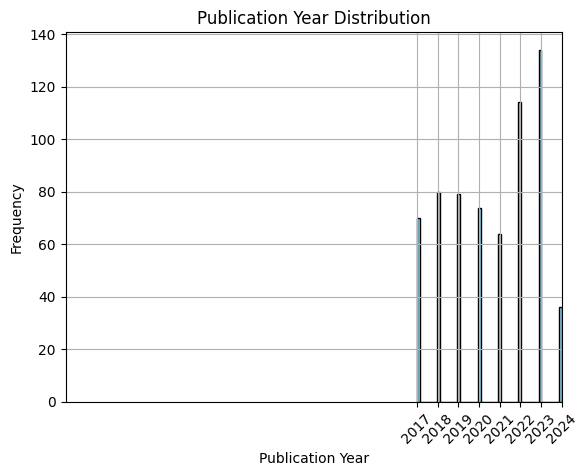

In [15]:
result_df['publication_year'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Publication Year Distribution')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Adjust the number of ticks on the x-axis
plt.xticks(ticks=range(result_df['publication_year'].min(), result_df['publication_year'].max() + 1, 1), rotation=45)
plt.xlim(2000,2024)

# Show the plot
plt.show()

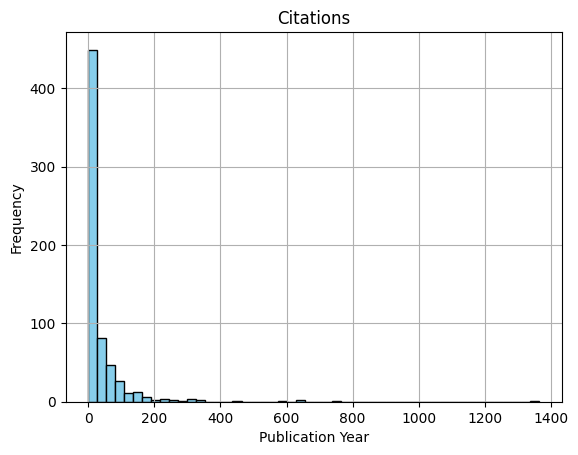

In [16]:
result_df['cited_by_count'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Citations')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Show the plot
plt.show()